# Práctica Actividad Supervisados Clasificación

El ejercicio consiste en clasificar si el cliente va a realizar una compra o no. Se debe obtener el mejor modelo de clasificación optimizado por recall. Se pide:

- EDA
- Preprocesamiento (tened en cuenta las particularidades de cada algoritmo)
- Fit de modelos
- Optmización de hiperparámetros

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn import svm
import sklearn.metrics as metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# EDA

In [22]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [24]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [25]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


La variable binaria "Purchased" muestra que el "1" representa la compra y el "0" no comprar, el promedio muestra que el 35.75% de los registros en este dataset corresponden a clientes que sí realizaron una compra. 

<Axes: xlabel='Purchased'>

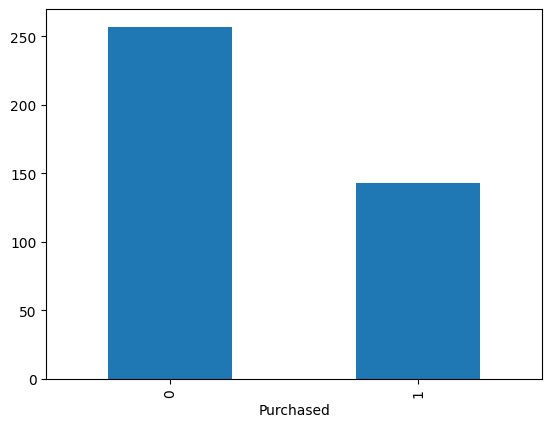

In [26]:
df["Purchased"].value_counts().plot(kind="bar")

El objetivo del ejercicio es optimizar el recall, es decir, encontrar a los compradores reales. Como se puede observar, el dataset está desbalanceado, lo que puede afectar el rendimiento de los modelos de clasificación. Por lo tanto, es importante tener en cuenta este desequilibrio en el momento de entrenar los modelos y evaluar su desempeño.

In [27]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1}) # codificamos la variable "Gender" a valores numéricos, para poder realizar análisis y modelado posteriormente.

<Axes: >

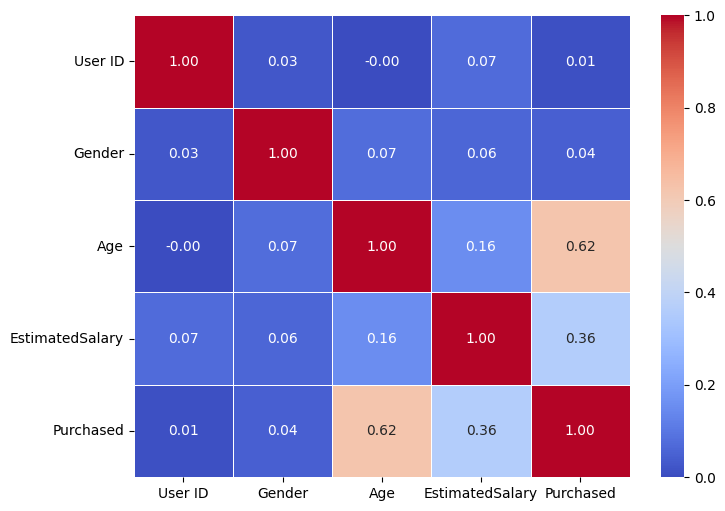

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(), 
            annot=True, 
            linewidths=0.5, 
            fmt= ".2f", 
            cmap="coolwarm")

Las relaciones más fuertes con la variable objetivo "Purchased" se encuentran en las variables "Age" y "EstimatedSalary", lo que sugiere que estas características podrían ser importantes para predecir si un cliente realizará una compra o no.

<Figure size 1500x1000 with 0 Axes>

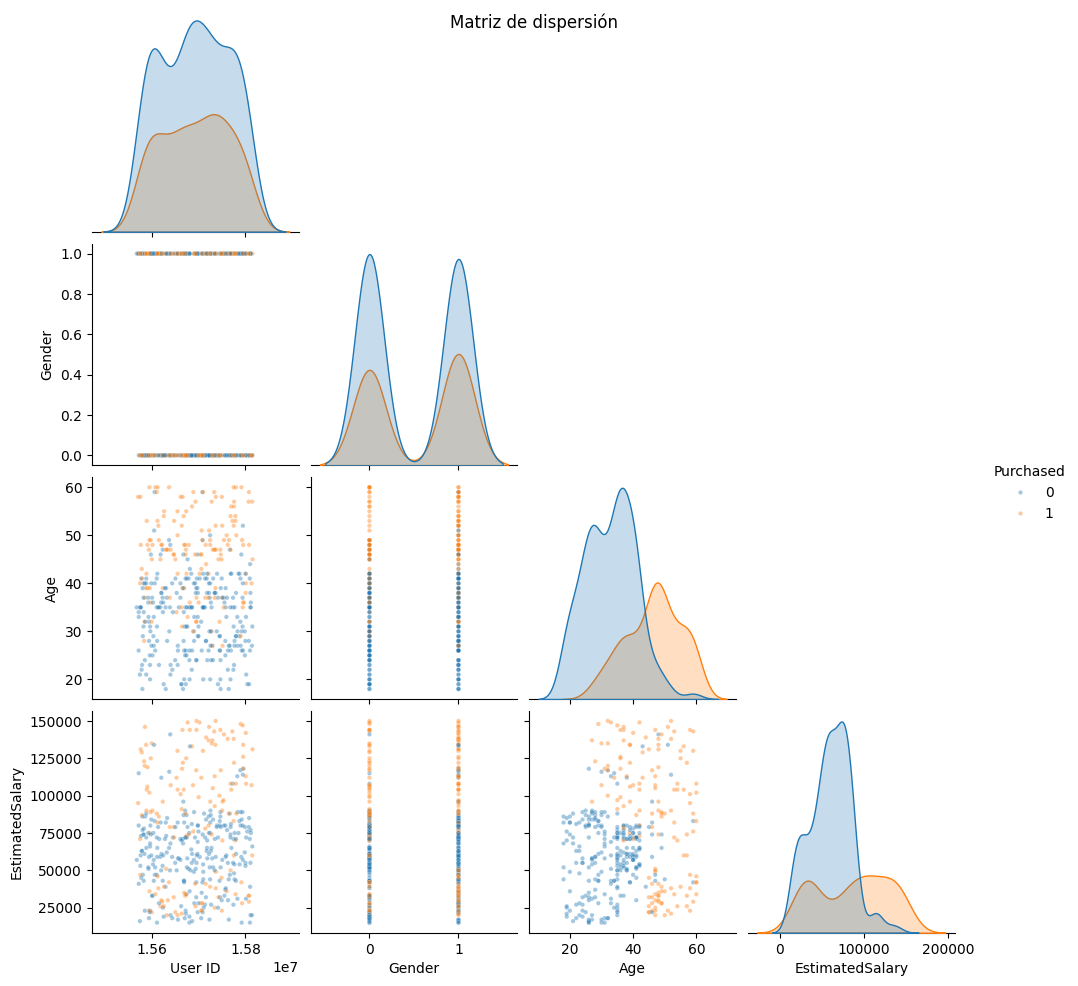

In [29]:
plt.figure(figsize=(15, 10))

sns.pairplot(df, diag_kind='kde', corner=True, plot_kws={'alpha': 0.4, 's': 10}, hue='Purchased')
plt.suptitle("Matriz de dispersión")
plt.show()

La personas que si compran se concentran en edades más avanzadas y salarios más altos

<Axes: xlabel='Purchased', ylabel='Age'>

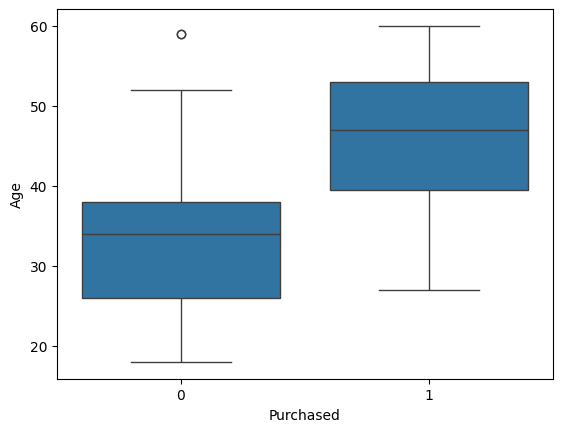

In [30]:
sns.boxplot(x="Purchased", y="Age", data=df)

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

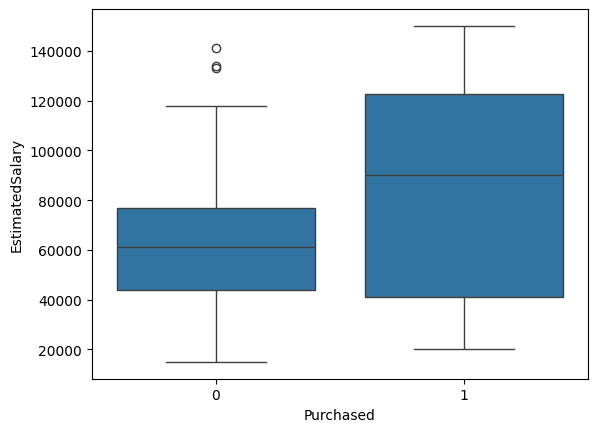

In [31]:
sns.boxplot(x="Purchased", y="EstimatedSalary", data=df)

La diferenciación por edad muestra que existe un separación clara entre clases, la mediana de los compradores es significativamente más alta que la de los no compradores, lo que sugiere que la edad es un factor importante en la decisión de compra. 

En la diferenciación por salario, hay un mayor solapamiento entre las clases. Esto significa que aunque el dienro importa, hay mucha gente con salarios medios que no compra y gente con salarios similares que si lo hace.

Ambas viasualizaciones muestran outliers, queriendo representar por ejemplo, alguin muy joven que compró o alguien con un sueldo altísimo que no compró. Po el momento vamos a mantenerlos en nuestros datos porque representan comportamientos reales que el modelo debe captar para maximizar el recall.

# Preprocesamiento

Los valores de la variable objetivo "Purchased" ya están codificados como 0 y 1, por lo que no es necesario realizar una codificación adicional. Lo mismo sucede con la variable "Gender", durante el EDA se convirtió a variable numérica, por lo que no es necesario realizar una codificación adicional. Todas las varibales son ya numéricas para poder empezar con el preprocesamiento correctamente.

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    int64
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(5)
memory usage: 15.8 KB


Definimos la variable objetivo "target" para facilitar su uso en los modelos de clasificación y las variables predictoras.

In [33]:
y = df["Purchased"]
X = df.drop("Purchased", axis=1)

Como se puede ver en el mapa de calor, la variables "User ID" es simplemente un identificador único que no tiene ninguna relación coon la compra o no de un cliente, la correlación que muestra es muy baja y mantenerla solo podrñia sesgar el resultado de nuestro modelo lo que podrís dificultar que se alcance un buen recall. Por ello vamos a eliminarla

In [34]:
df.drop("User ID", axis=1, inplace=True)

Normalizo los datos para que todos los modelos predigan de forma correcta. Realizo también el split entre train y test de nuestra muestra, con un stratify ya que vamos a hacer una clasificación.

In [35]:
df_norm = StandardScaler()
X = df_norm.fit_transform(X)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [37]:
print("Shape of X_train {}".format(X_train.shape))
print("Shape of X_test {}".format(X_test.shape))
print("Shape of y_train {}".format(y_train.shape))
print("Shape of y_test {}".format(y_test.shape))

Shape of X_train (300, 4)
Shape of X_test (100, 4)
Shape of y_train (300,)
Shape of y_test (100,)


# MODELADO

In [38]:
models = {"Logistic Regression": LogisticRegression(),
        "KNN": KNeighborsClassifier(),
        "Decission Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(), 
        "XGBoost": xgb.XGBClassifier(),
        "SVM": svm.SVC()}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    model_scores = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_preds = model.predict(X_test)
        model_scores[name] = round(metrics.recall_score(y_test, y_preds),3)
    return model_scores

In [39]:
model_scores = fit_and_score(models=models,
                            X_train=X_train,
                            X_test=X_test,
                            y_train=y_train,
                            y_test=y_test)
model_scores

{'Logistic Regression': 0.639,
 'KNN': 0.833,
 'Decission Tree': 0.778,
 'Random Forest': 0.861,
 'XGBoost': 0.833,
 'SVM': 0.833}

<Axes: >

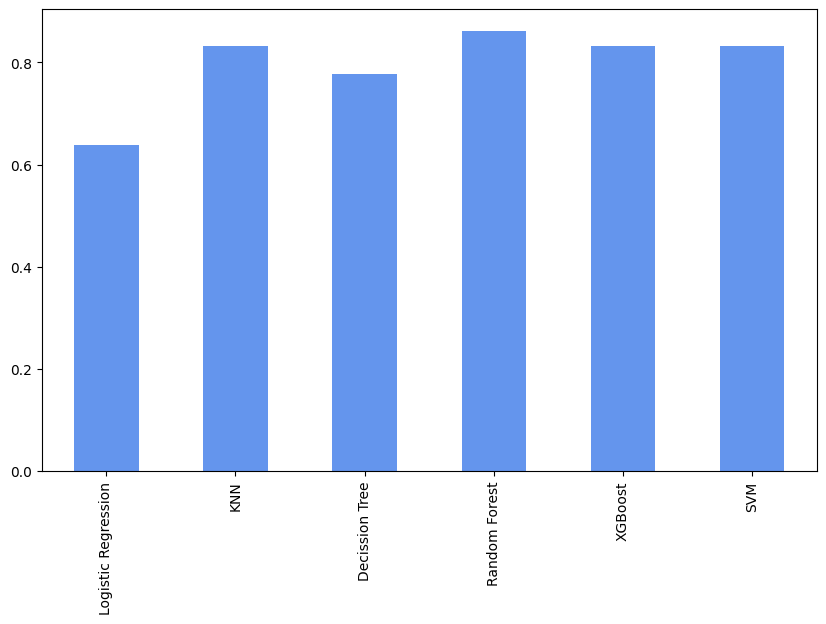

In [40]:
pd.Series(model_scores).plot.bar(figsize=(10,6), color='cornflowerblue')

Como se puede ver, el RandomForest maximiza la métrica del recall. Esto quiere decir que, usando el modelo de RandomForest, somos capaces de identificar correctamente 86 compradores de un grupo de 100 potenciales clientes. Habiendo establecido una base sobre lo modelo más prometedores vamos a realizar el modelo con optimización de parámetros para estos 4 modelos: KNN, RandomForest, XGBoost y SVM

### KNN - optimizado

In [41]:
param_grid_KNN = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_KNN = GridSearchCV(KNeighborsClassifier(), 
                            param_grid_KNN, 
                            scoring='recall')

grid_search_KNN.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [44]:
print(f"Los mejores parámetros son: {grid_search_KNN.best_params_}")

RC_train_KNN = round(grid_search_KNN.best_score_, 3)
RC_test_KNN = round(metrics.recall_score(y_test, grid_search_KNN.predict(X_test)), 3)

print(f"El mejor Recall obtenido en validación: {RC_train_KNN}")
print(f"El Recall obtenido en test: {RC_test_KNN}")

Los mejores parámetros son: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
El mejor Recall obtenido en validación: 0.868
El Recall obtenido en test: 0.833


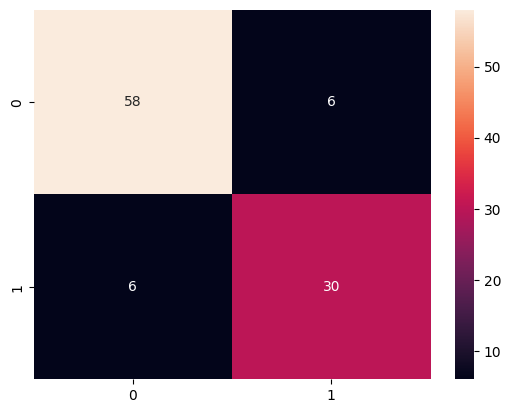

In [47]:
y_test_pred_KNN = grid_search_KNN.predict(X_test)

sns.heatmap(metrics.confusion_matrix(y_test, y_test_pred_KNN),
            annot=True)
plt.show()

### RandomForest - optimizado

In [48]:
param_grid_RF = {"n_estimators" : [10, 50, 100, 200],
                "max_depth" : [None, 5, 7, 9, 13],
                "max_features": [10, "sqrt"]}

grid_search_RF = GridSearchCV(RandomForestClassifier(), 
                            param_grid_RF, 
                            scoring='recall')

grid_search_RF.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': [10, 'sqrt'], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [49]:
print(f"Los mejores parámetros son: {grid_search_RF.best_params_}")

RC_train_RF = round(grid_search_RF.best_score_, 3)
RC_test_RF = round(metrics.recall_score(y_test, grid_search_RF.predict(X_test)), 3)

print(f"El mejor Recall obtenido en validación: {RC_train_RF}")
print(f"El Recall obtenido en test: {RC_test_RF}")

Los mejores parámetros son: {'max_depth': 5, 'max_features': 10, 'n_estimators': 100}
El mejor Recall obtenido en validación: 0.934
El Recall obtenido en test: 0.861


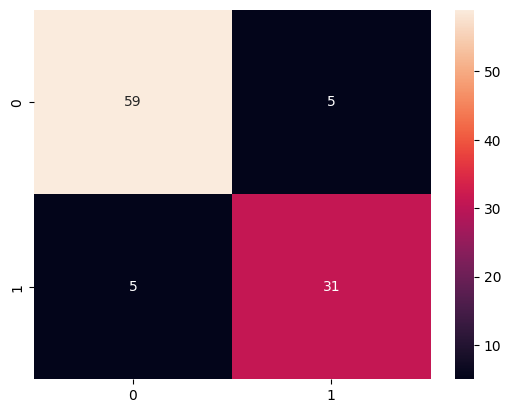

In [50]:
y_test_pred_RF = grid_search_RF.predict(X_test)

sns.heatmap(metrics.confusion_matrix(y_test, y_test_pred_RF),
            annot=True)
plt.show()

### XGBoost - optimizado

In [51]:
param_grid_XGB = {"n_estimators" : [100, 500],
          "max_depth"    : range(2, 8),
          "eta"          : [0.05, 0.1, 0.2],
          "lambda":[0.2, 1.0, 2.0],
          "subsample":[0.6, 0.8, 1.0]
}

grid_search_XGB = GridSearchCV(xgb.XGBClassifier(), 
                              param_grid_XGB, 
                            scoring='recall')

grid_search_XGB.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'eta': [0.05, 0.1, ...], 'lambda': [0.2, 1.0, ...], 'max_depth': range(2, 8), 'n_estimators': [100, 500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [52]:
print(f"Los mejores parámetros son: {grid_search_XGB.best_params_}")

RC_train_XGB = round(grid_search_XGB.best_score_, 3)
RC_test_XGB = round(metrics.recall_score(y_test, grid_search_XGB.predict(X_test)), 3)

print(f"El mejor Recall obtenido en validación: {RC_train_XGB}")
print(f"El Recall obtenido en test: {RC_test_XGB}")

Los mejores parámetros son: {'eta': 0.05, 'lambda': 2.0, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.6}
El mejor Recall obtenido en validación: 0.924
El Recall obtenido en test: 0.889


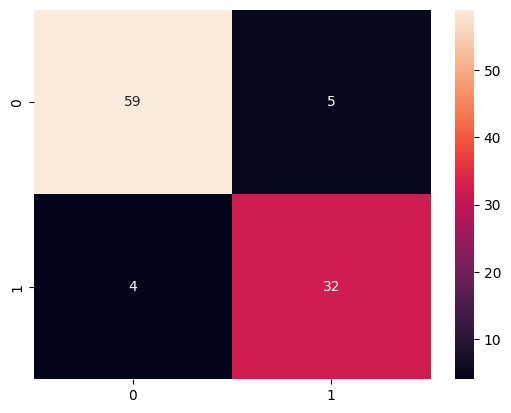

In [53]:
y_test_pred_XGB = grid_search_XGB.predict(X_test)

sns.heatmap(metrics.confusion_matrix(y_test, y_test_pred_XGB),
            annot=True)
plt.show()

### SVM - optimizado

In [54]:
param_grid_SVM = {"C": [0.1, 1, 10, 100],
                  "kernel": ['linear', 'rbf'],
                  "gamma": ['scale', 'auto']
}

grid_search_SVM = GridSearchCV(svm.SVC(), 
                              param_grid_SVM, 
                            scoring='recall')

grid_search_SVM.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [55]:
print(f"Los mejores parámetros son: {grid_search_XGB.best_params_}")

RC_train_SVM = round(grid_search_SVM.best_score_, 3)
RC_test_SVM = round(metrics.recall_score(y_test, grid_search_SVM.predict(X_test)), 3)

print(f"El mejor Recall obtenido en validación: {RC_train_SVM}")
print(f"El Recall obtenido en test: {RC_test_SVM}")

Los mejores parámetros son: {'eta': 0.05, 'lambda': 2.0, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.6}
El mejor Recall obtenido en validación: 0.897
El Recall obtenido en test: 0.833


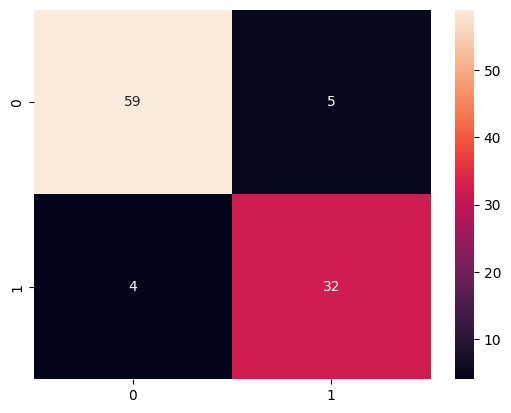

In [56]:
y_test_pred_XGB = grid_search_XGB.predict(X_test)

sns.heatmap(metrics.confusion_matrix(y_test, y_test_pred_XGB),
            annot=True)
plt.show()

In [57]:
RC_table = pd.DataFrame({
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'SVM'],
    'Recall train': [RC_train_KNN, RC_train_RF, RC_train_XGB, RC_train_SVM],
    'Recall test': [RC_test_KNN, RC_test_RF, RC_test_XGB, RC_test_SVM]
})

RC_table.sort_values('Recall test', ascending=False)

,Modelo,Recall train,Recall test
2,XGBoost,0.924,0.889
1,Random Forest,0.934,0.861
0,KNN,0.868,0.833
3,SVM,0.897,0.833


Realizando un análisis de los recall obternidos en los modelos optimizados, se puede observar que el modelo de Random Forest es el que obtiene el mejor recall  en train, sin ambargo, su recall obtenido en test es de los más bajos teniendo también una diferencia grande entre train y test. Esto puede sugerir que el modelo de Random Forest está sobreajustado, lo que significa que no generalizan bien a nuevos datos.

El mejor modelo que balancea el recall obtenido en train y test es el modelo de XGBoost, con un recall de 0.924 en train y 0.889 en test tras optimizar parámetros. Esto indica que el modelo de XGBoost es capaz de identificar correctamente a los compradores reales tanto en el conjunto de entrenamiento como en el conjunto de prueba, lo que sugiere que es un modelo robusto y generalizable para este problema de clasificación.

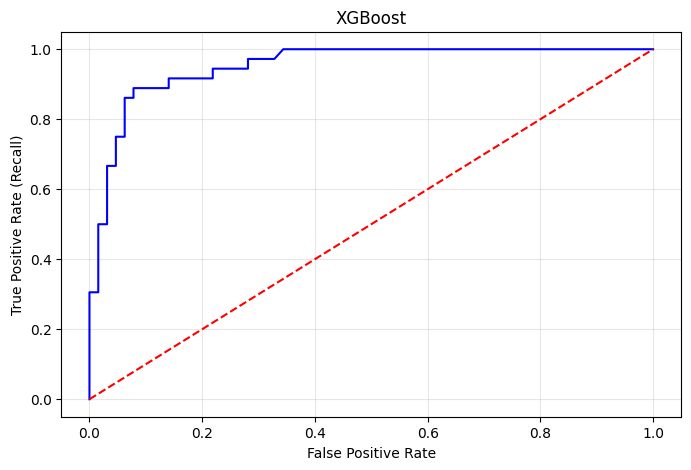

In [58]:
y_test_pred_prob = grid_search_XGB.predict_proba(X_test)
preds = y_test_pred_prob[:, 1]
fpr, tpr, umbral = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(8,5))
plt.title('XGBoost')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
#plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
#plt.xlim([0, 1])
#plt.ylim([0, 1])
plt.ylabel('True Positive Rate (Recall)')
plt.xlabel('False Positive Rate')
plt.grid(alpha=0.3)
plt.show()

La curva ROC del modelo de XGBoost muestra un área bajo la curva (AUC) de 0.95, lo que indica un excelente rendimiento en la clasificación de compradores y no compradores. Esto refuerza la conclusión de que el modelo de XGBoost es el más adecuado para este problema, ya que no solo tiene un buen recall, sino también una alta capacidad para distinguir entre las clases.